# 04 — Raw FPD image processing

This notebook demonstrates how to load FPD raw image event data.

Raw FPD image format:

```text
X ; Y ; Channel1 ; Channel2 ; Channel3 ; ...
```

Each row corresponds to one pixel coordinate. The remaining entries are the detector
channel numbers for ion events detected at that pixel.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pymagsims.raw_image import SIMSRawImage
from pymagsims.plotting import plot_ion_image

DATA = Path("../tests/data")
raw = SIMSRawImage.from_fpd_raw(DATA / "FPD_image2.raw")

## Metadata summary

In [2]:
raw.metadata

{'source': 'FPD raw image',
 'n_pixels_with_rows': 254371,
 'n_events': 12962825,
 'x_min': 0,
 'x_max': 511,
 'y_min': 1,
 'y_max': 511,
 'channel_min': 0,
 'channel_max': 11309}

## Total ion image

(511, 512) 12962825


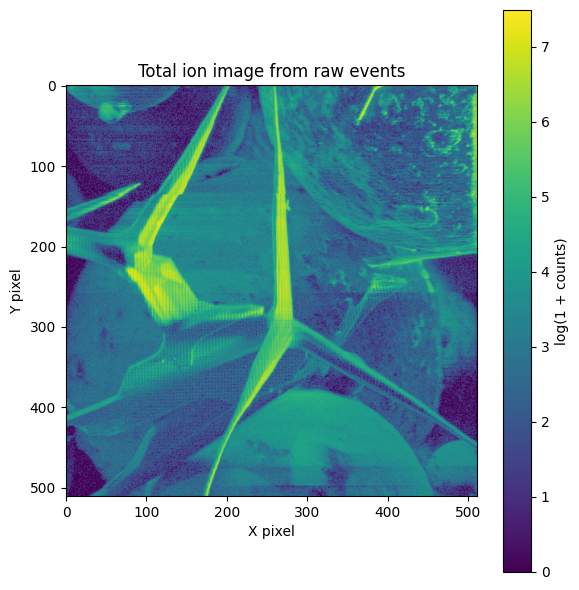

In [3]:
tic = raw.total_ion_image()
print(tic.shape, tic.sum())

plot_ion_image(tic, log=True, title="Total ion image from raw events");

## Image from a detector-channel bin

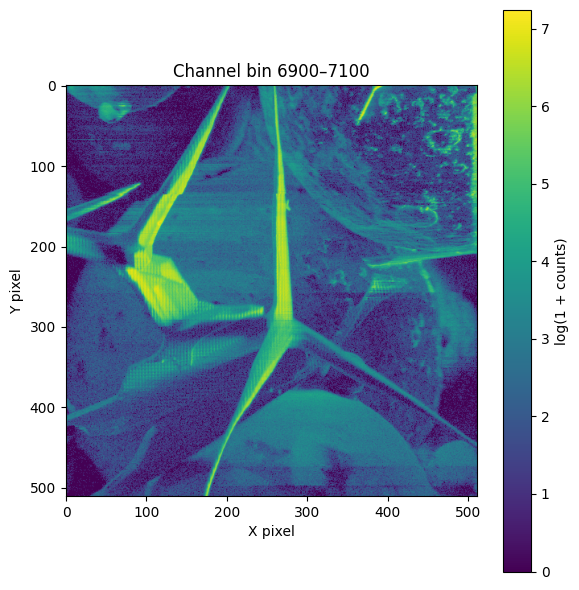

In [4]:
ch_img = raw.image_from_channel_bin(6900, 7100)

plot_ion_image(ch_img, log=True, title="Channel bin 6900–7100");